In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import pandas as pd
df = pd.read_csv("housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [26]:
y = df["median_house_value"]
x = df.drop("median_house_value" , axis=1)

In [27]:
df.info('ocean_proximity')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [28]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [29]:
print(len(x_train))
print(len(x_test))

16512
4128


In [30]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


In [31]:
def build_pipeline(num_attribs, cat_attribs):
    num_pipeline = Pipeline([ 
       ( "imputer" , SimpleImputer(strategy = "median")),
        ("Scaler" , StandardScaler())
    ]) 
    cat_pipeline =Pipeline([
        ("onehot" , OneHotEncoder(handle_unknown = "ignore"))
    ])
    full_pipeline = ColumnTransformer([
        ("num" , num_pipeline, num_attribs),
        ("cat" , cat_pipeline , cat_attribs)
    ])
    return full_pipeline
    

In [32]:
num_attribs =x_train.drop("ocean_proximity", axis =1).columns.tolist()
cat_attribs =["ocean_proximity"]
pipeline = build_pipeline(num_attribs, cat_attribs)

In [33]:
x_train_prepared = pipeline.fit_transform(x_train)

In [34]:
model = LinearRegression()
model.fit(x_train_prepared, y_train)

LinearRegression()

In [35]:
x_test_prepared = pipeline.transform(x_test)
predictions = model.predict(x_test_prepared)

In [36]:
print(predictions[:5])

[ 54261.02768976 124430.91772796 255694.95828244 268208.01035997
 262975.01360647]


In [37]:
from sklearn.metrics import root_mean_squared_error
rmse = root_mean_squared_error(y_test, predictions)
print(rmse)

70059.19333925012


In [38]:
from sklearn.ensemble import RandomForestRegressor

In [39]:
model_rf = RandomForestRegressor()
model_rf.fit(x_train_prepared , y_train)
                            

RandomForestRegressor()

In [40]:
x_train_prepared = pipeline.transform(x_train)
predictions = model_rf.predict(x_train_prepared)

In [41]:
print(predictions[:5])

[108018. 363027. 177356.  89108.  94135.]


In [42]:
x_test_prepared = pipeline.transform(x_test)
predictions_test = model_rf.predict(x_test_prepared)
rmse_test = root_mean_squared_error(y_test, predictions_test)
print(rmse_test)

48827.96990116998


In [43]:
results = pd.DataFrame({
    "original Price": y_test.values,
    "Predicted Price": predictions_test.astype(int)
})
results["Fark"] = (results["original Price"] - results["Predicted Price"]).astype(int)
print(results)
results.to_csv("housing_predictions.csv", index=False)


      original Price  Predicted Price   Fark
0            47700.0            49915  -2215
1            45800.0            70444 -24644
2           500001.0           472290  27711
3           218600.0           242910 -24310
4           278000.0           271010   6990
...              ...              ...    ...
4123        263300.0           205978  57322
4124        266800.0           239770  27030
4125        500001.0           499538    463
4126         72300.0            70481   1819
4127        151500.0           169713 -18213

[4128 rows x 3 columns]


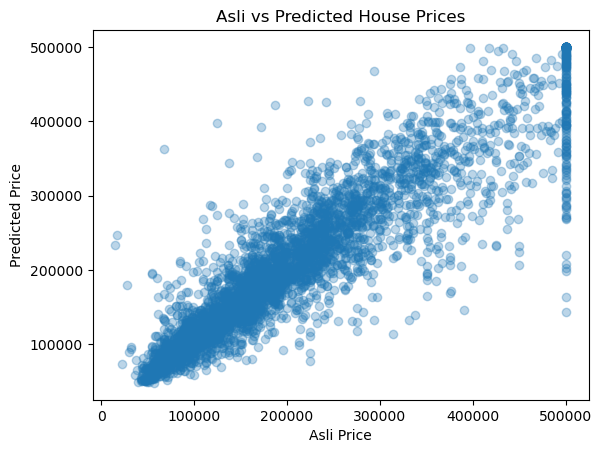

In [44]:
import matplotlib.pyplot as plt

plt.scatter(y_test, predictions_test, alpha=0.3)
plt.xlabel("Asli Price")
plt.ylabel("Predicted Price")
plt.title("Asli vs Predicted House Prices")
plt.show()

In [45]:
import os 
import joblib 
print(os.path.exists("housing_model.pkl"))

True


In [46]:
loaded_model = joblib.load("housing_model.pkl")
loaded_pipeline = joblib.load("housing_pipeline.pkl")

In [47]:
loaded_pipeline.transform(x_test )
x_test_new = loaded_pipeline.transform(x_test )

In [48]:
loaded_model.predict(x_test_new)

array([ 50405.  ,  72224.  , 457029.39, ..., 499694.99,  70285.  ,
       173113.  ])

In [49]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, predictions_test)
print("R2 Score:", r2)

R2 Score: 0.8180590423098226


In [50]:
import streamlit as st



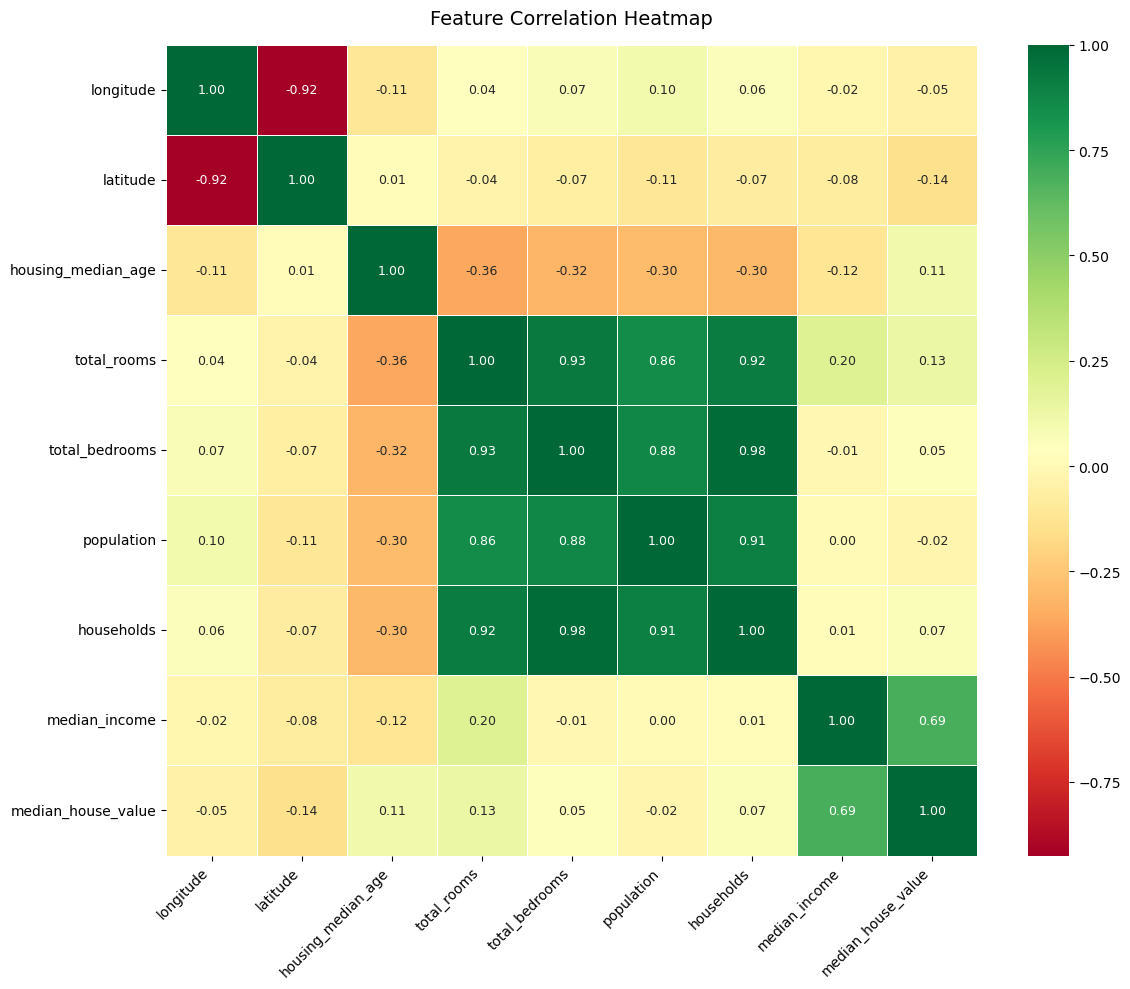

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))
sns.heatmap(df.select_dtypes(include='number').corr(), 
            annot=True, 
            fmt='.2f', 
            cmap='RdYlGn',
            linewidths=0.5,
            annot_kws={'size': 9})
plt.title('Feature Correlation Heatmap', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_16400\1472468316.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x='Importance', y='Feature', palette='viridis')


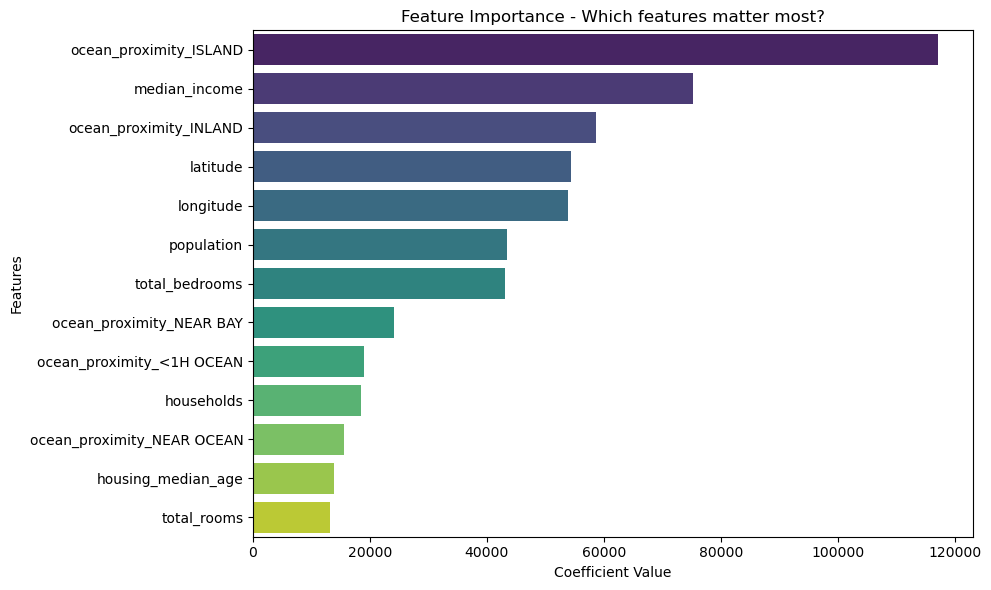

In [52]:
cat_features = pipeline.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(['ocean_proximity']).tolist()
all_features = num_attribs + cat_features

coef_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': abs(model.coef_)
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=coef_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance - Which features matter most?')
plt.xlabel('Coefficient Value')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# Observation: Higher coefficient = more impact on house price prediction

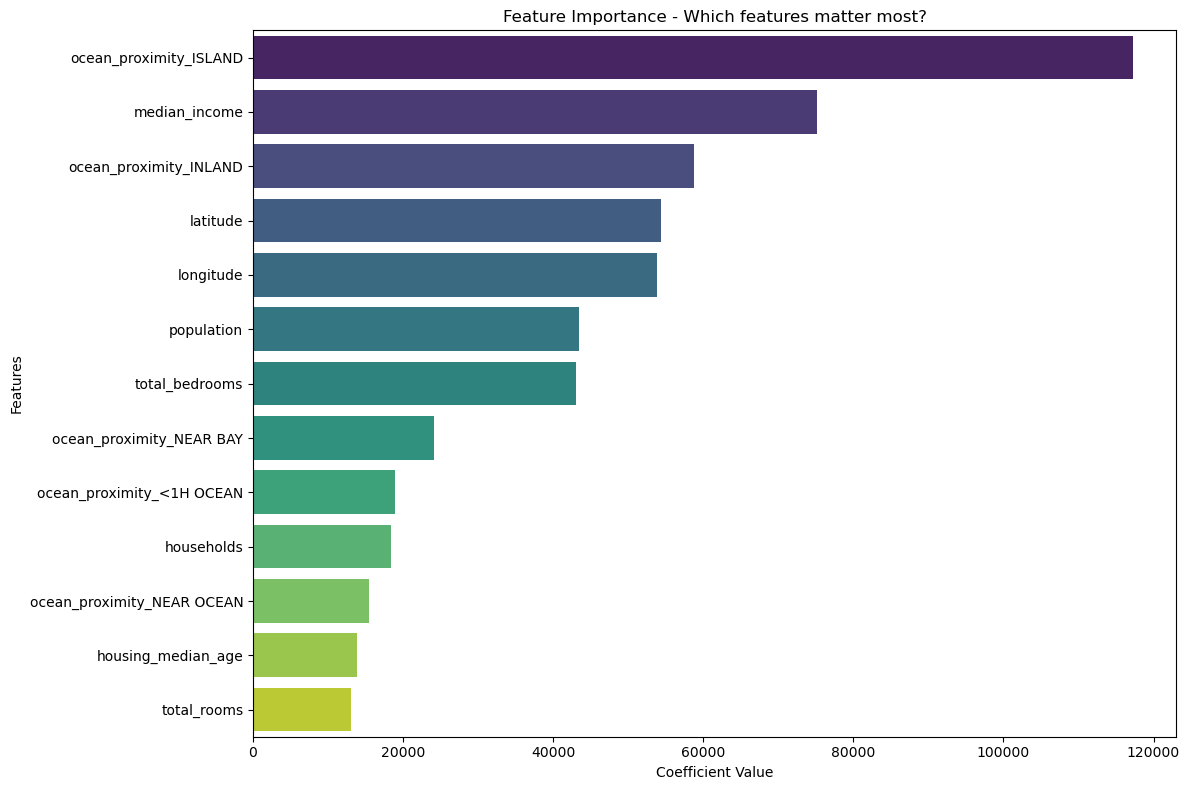

<Figure size 640x480 with 0 Axes>

In [53]:

plt.figure(figsize=(12,8))
sns.barplot(data=coef_df, x='Importance', y='Feature', hue='Feature', legend=False, palette='viridis')
plt.title('Feature Importance - Which features matter most?')
plt.xlabel('Coefficient Value')
plt.ylabel('Features')
plt.tight_layout()
plt.show()
plt.tight_layout()

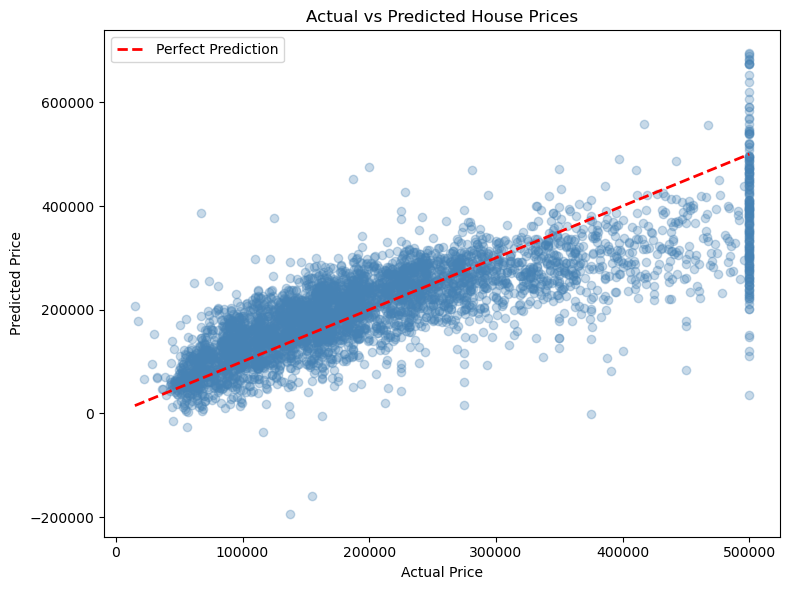

In [54]:
y_pred = model.predict(pipeline.transform(x_test))

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue')
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')
plt.legend()
plt.tight_layout()
plt.show()

# Points closer to red line = accurate predictions

In [55]:
import joblib 
joblib.dump(model_rf, "housing_model.pkl")
joblib.dump(pipeline,"housing_pipeline.pkl")
print("Model Svaed")

Model Svaed


In [61]:
from xgboost import XGBRegressor

In [60]:
model_xgb = XGBRegressor()
model_xgb.fit(x_train_prepared , y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [65]:
prediction_xgb = model_xgb.predict(x_test_prepared)


In [69]:
rmse = root_mean_squared_error(y_test , prediction_xgb)
r2 = r2_score(y_test , prediction_xgb)
                               

In [70]:
r2

0.8270020909155706

In [72]:
print(root_mean_squared_error(y_test , prediction_xgb))

47612.81479613856


In [73]:
joblib.dump(model_xgb , "xgb_model.pkl")

['xgb_model.pkl']